# ETA előrejelzés NYC Yellow Taxi adatokon

## Lineáris regresszió és interpretálhatóság

Ebben a notebookban a `clean_data/2009` adatokból építünk ETA (Estimated Time of Arrival) modellt.
A célváltozó: `trip_duration_minutes` (az út időtartama percben).

A notebook célja egyszerre:
1. **jó baseline modell** készítése (`LinearRegression`),
2. **hiperparaméter-választás** bemutatása (`Ridge`/`Lasso` + `GridSearchCV`),
3. **értelmezhetőség** biztosítása (koefficiensek + permutation importance).

Referencia: Christoph Molnar – *Interpretable Machine Learning*
https://christophm.github.io/interpretable-ml-book/

## Elméleti háttér röviden

A lineáris regresszió modell alakja:

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p
$$

ahol:
- $\hat{y}$: becsült ETA percben,
- x_i: bemeneti jellemzők (távolság, koordináták, időjellemzők),
- $\beta_i$: modellparaméterek (koefficiensek).

Interpretáció:
- a koefficiens előjele mutatja az irányt (növeli/csökkenti a becslést),
- nagysága a hatás erősségét mutatja (a többi változó rögzítése mellett).

In [32]:
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.dataset as ds
from IPython.display import display

from sklearn.base import clone
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [33]:
# --- Konfiguráció ---
DATA_DIR = Path('clean_data/2009')
PARQUET_FILES = sorted(DATA_DIR.glob('*.parquet'))

if not PARQUET_FILES:
    raise FileNotFoundError(f'Nincsenek parquet fájlok itt: {DATA_DIR.resolve()}')

# Egy közös korlát: ennyi sort olvasunk be és legfeljebb ennyit használunk tanításhoz
USE_SAMPLE = True
MAX_ROWS = 2_000_000

BATCH_SIZE = 250_000

print(f'Fájlok száma: {len(PARQUET_FILES)}')

Fájlok száma: 12


## Miért batch-es beolvasás?

A teljes 2009-es állomány nagyon nagy lehet (több tízmillió sor), ezért nem célszerű egyszerre memóriába tölteni.
A `pyarrow.dataset` scanner batch-ekben olvas, így stabilabb és memóriahatékonyabb a futás.

In [34]:
dataset = ds.dataset([str(path) for path in PARQUET_FILES], format='parquet')
scanner = dataset.scanner(batch_size=BATCH_SIZE, use_threads=True)

chunks = []
rows_loaded = 0

for i, rb in enumerate(scanner.to_batches(), start=1):
    chunk = rb.to_pandas(split_blocks=True, self_destruct=True)
    chunks.append(chunk)
    rows_loaded += len(chunk)

    if i % 5 == 0:
        print(f'Batch {i}: rows_loaded={rows_loaded:,}')

    if USE_SAMPLE and rows_loaded >= MAX_ROWS:
        break

df = pd.concat(chunks, ignore_index=True)
if USE_SAMPLE and len(df) > MAX_ROWS:
    df = df.iloc[:MAX_ROWS]

print(f'Beolvasott sorok: {len(df):,}')
display(df.head())

Batch 5: rows_loaded=1,000,000
Batch 10: rows_loaded=2,000,000
Beolvasott sorok: 2,000,000


,pickup_at,dropoff_at,passenger_count,trip_distance,pickup_lon,pickup_lat,dropoff_lon,dropoff_lat
0,2009-01-04 02:52:00,2009-01-04 03:02:00,1,2.63,-73.991957,40.721567,-73.993803,40.695922
1,2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,-73.982102,40.736290,-73.955850,40.768030
2,2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,-74.002587,40.739748,-73.869983,40.770225
3,2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.00,-73.974267,40.790955,-73.996558,40.731849
4,2009-01-24 16:18:23,2009-01-24 16:24:56,1,0.40,-74.001580,40.719382,-74.008378,40.720350


## Célváltozó és feature engineering

A célváltozót időbélyegekből számoljuk:

`trip_duration_minutes = (dropoff_at - pickup_at)` percben.

Szűrések:
- hiányzó időpontok törlése,
- irreális időtartamok szűrése (`1..300` perc).

Új időfeature-ök:
- indulás órája (`pickup_hour`),
- hét napja (`pickup_weekday`),
- hónap (`pickup_month`).

In [35]:
df['pickup_at'] = pd.to_datetime(df['pickup_at'], errors='coerce')
df['dropoff_at'] = pd.to_datetime(df['dropoff_at'], errors='coerce')
df['trip_duration_minutes'] = (df['dropoff_at'] - df['pickup_at']).dt.total_seconds() / 60.0

df = df.dropna(subset=['pickup_at', 'dropoff_at', 'trip_duration_minutes'])
df = df[df['trip_duration_minutes'].between(1, 300)]

df['pickup_hour'] = df['pickup_at'].dt.hour
df['pickup_weekday'] = df['pickup_at'].dt.weekday
df['pickup_month'] = df['pickup_at'].dt.month

feature_cols = [
    'passenger_count', 'trip_distance',
    'pickup_lon', 'pickup_lat', 'dropoff_lon', 'dropoff_lat',
    'pickup_hour', 'pickup_weekday', 'pickup_month',
]

for col in feature_cols + ['trip_duration_minutes']:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('float32')

model_df = df.loc[:, feature_cols + ['trip_duration_minutes']].dropna()
if len(model_df) > MAX_ROWS:
    model_df = model_df.sample(n=MAX_ROWS, random_state=42)

print(f'Modellsorok száma (tanításhoz): {len(model_df):,}')
display(model_df.head())

Modellsorok száma (tanításhoz): 1,950,678


,passenger_count,trip_distance,pickup_lon,pickup_lat,dropoff_lon,dropoff_lat,pickup_hour,pickup_weekday,pickup_month,trip_duration_minutes
0,1.0,2.63,-73.991959,40.721565,-73.993805,40.695923,2.0,6.0,1.0,10.000000
1,3.0,4.55,-73.982101,40.736290,-73.955849,40.768028,3.0,6.0,1.0,7.000000
2,5.0,10.35,-74.002586,40.739746,-73.869980,40.770226,15.0,5.0,1.0,14.000000
3,1.0,5.00,-73.974266,40.790955,-73.996559,40.731850,20.0,3.0,1.0,21.033333
4,1.0,0.40,-74.001579,40.719383,-74.008377,40.720348,16.0,5.0,1.0,6.550000


## Baseline modell tanítása (OLS)

Itt két lineáris modellt tanítunk:
- `model_std`: skálázott OLS (összehasonlíthatóbb koefficiensekhez),
- `model_raw`: nyers OLS (mértékegységben értelmezhető koefficiensekhez).

In [36]:
X = model_df[feature_cols]
y = model_df['trip_duration_minutes']

# 1) Végső, érintetlen teszthalmaz
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2) A train részből külön dev set a modellválasztáshoz
X_train, X_dev, y_train, y_dev = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

model_std = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression()),
])
model_std.fit(X_train, y_train)

model_raw = LinearRegression()
model_raw.fit(X_train, y_train)

pred_ols_dev = model_std.predict(X_dev)

print(f'OLS MAE  (dev): {mean_absolute_error(y_dev, pred_ols_dev):.3f}')
print(f'OLS RMSE (dev): {np.sqrt(mean_squared_error(y_dev, pred_ols_dev)):.3f}')
print(f'OLS R2   (dev): {r2_score(y_dev, pred_ols_dev):.4f}')


OLS MAE  (dev): 3.493
OLS RMSE (dev): 6.052
OLS R2   (dev): 0.4900


## 2. mérföldkő: hiperparaméter-választás és modell-összehasonlítás (dev set alapon)

`Ridge` és `Lasso` modelleknél az `alpha` szabályozza a regularizáció erősségét.
A legjobb `alpha` értéket `GridSearchCV`-vel, 3-szoros keresztvalidációval választjuk a tanító adaton,
majd a modellek közti választást **dev seten** végezzük.
A `test` halmazt csak a végső, egyszeri teljesítménymérésre használjuk.


In [37]:
tune_rows = min(500_000, len(X_train))
X_train_tune = X_train.sample(n=tune_rows, random_state=42)
y_train_tune = y_train.loc[X_train_tune.index]

cv = KFold(n_splits=3, shuffle=True, random_state=42)
alpha_grid = {'reg__alpha': np.logspace(-2, 2, 8)}

ridge_pipe = Pipeline([('scaler', StandardScaler()), ('reg', Ridge(solver='svd'))])
lasso_pipe = Pipeline([('scaler', StandardScaler()), ('reg', Lasso(max_iter=20_000))])

ridge_grid = GridSearchCV(ridge_pipe, alpha_grid, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
lasso_grid = GridSearchCV(lasso_pipe, alpha_grid, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)

# Hyperparaméter-hangolás csak train adaton
ridge_grid.fit(X_train_tune, y_train_tune)
lasso_grid.fit(X_train_tune, y_train_tune)

best_ridge_dev = ridge_grid.best_estimator_
best_lasso_dev = lasso_grid.best_estimator_

# Dev set alapú modellösszehasonlítás
pred_ols_dev = model_std.predict(X_dev)
pred_ridge_dev = best_ridge_dev.predict(X_dev)
pred_lasso_dev = best_lasso_dev.predict(X_dev)

comparison_dev_df = pd.DataFrame([
    {
        'model': 'LinearRegression (OLS)',
        'MAE': mean_absolute_error(y_dev, pred_ols_dev),
        'RMSE': np.sqrt(mean_squared_error(y_dev, pred_ols_dev)),
        'R2': r2_score(y_dev, pred_ols_dev),
    },
    {
        'model': 'Ridge (best alpha)',
        'MAE': mean_absolute_error(y_dev, pred_ridge_dev),
        'RMSE': np.sqrt(mean_squared_error(y_dev, pred_ridge_dev)),
        'R2': r2_score(y_dev, pred_ridge_dev),
    },
    {
        'model': 'Lasso (best alpha)',
        'MAE': mean_absolute_error(y_dev, pred_lasso_dev),
        'RMSE': np.sqrt(mean_squared_error(y_dev, pred_lasso_dev)),
        'R2': r2_score(y_dev, pred_lasso_dev),
    },
])

ranking_df = comparison_dev_df.copy()
ranking_df['rank_mae'] = ranking_df['MAE'].rank(method='min', ascending=True)
ranking_df['rank_rmse'] = ranking_df['RMSE'].rank(method='min', ascending=True)
ranking_df['rank_r2'] = ranking_df['R2'].rank(method='min', ascending=False)
ranking_df['rank_mean'] = ranking_df[['rank_mae', 'rank_rmse', 'rank_r2']].mean(axis=1)
ranking_df = ranking_df.sort_values(['rank_mean', 'MAE']).reset_index(drop=True)

model_registry_dev = {
    'LinearRegression (OLS)': model_std,
    'Ridge (best alpha)': best_ridge_dev,
    'Lasso (best alpha)': best_lasso_dev,
}

selected_model_name = ranking_df.loc[0, 'model']

# A kiválasztott modellt újratanítjuk train+dev adaton, majd egyszer mérünk testen
selected_model = clone(model_registry_dev[selected_model_name])
selected_model.fit(X_train_full, y_train_full)

# A teljes (train+dev) adaton újratanított modellek az ETA-összehasonlításhoz
model_registry = {
    'LinearRegression (OLS)': clone(model_std).fit(X_train_full, y_train_full),
    'Ridge (best alpha)': clone(best_ridge_dev).fit(X_train_full, y_train_full),
    'Lasso (best alpha)': clone(best_lasso_dev).fit(X_train_full, y_train_full),
}

# Végső (egyszeri) tesztmetrikák
pred_test = selected_model.predict(X_test)
test_mae = mean_absolute_error(y_test, pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
test_r2 = r2_score(y_test, pred_test)

print('Dev set model összehasonlítás:')
display(comparison_dev_df.sort_values('MAE').reset_index(drop=True))
print('Dev set rangsor (összesített):')
display(ranking_df)
print(f'Kiválasztott modell (dev alapján): {selected_model_name}')
print('Végső test metrikák (egyszeri mérés):')
print(f'- MAE : {test_mae:.6f}')
print(f'- RMSE: {test_rmse:.6f}')
print(f'- R2  : {test_r2:.6f}')


Dev set model összehasonlítás:


,model,MAE,RMSE,R2
0,Ridge (best alpha),3.492993,6.052218,0.489974
1,LinearRegression (OLS),3.493261,6.052303,0.489960
2,Lasso (best alpha),3.494216,6.052584,0.489912


Dev set rangsor (összesített):


,model,MAE,RMSE,R2,rank_mae,rank_rmse,rank_r2,rank_mean
0,Ridge (best alpha),3.492993,6.052218,0.489974,1.0,1.0,1.0,1.0
1,LinearRegression (OLS),3.493261,6.052303,0.489960,2.0,2.0,2.0,2.0
2,Lasso (best alpha),3.494216,6.052584,0.489912,3.0,3.0,3.0,3.0


Kiválasztott modell (dev alapján): Ridge (best alpha)
Végső test metrikák (egyszeri mérés):
- MAE : 3.506392
- RMSE: 6.001449
- R2  : 0.495043


## Interpretálhatóság

### 1) Koefficiensek (globális modellmagyarázat)
- `coef_raw_units`: nyers egységű hatás (mértékegységben értelmezhető),
- `coef_standardized`: skálázott hatás (feature-ök közötti összehasonlításhoz).

### 2) Permutation importance (modell-független)
A feature értékeinek összekeverésével mérjük, mennyit romlik a modell teljesítménye.
Minél nagyobb a romlás, annál fontosabb a feature.

In [38]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef_raw_units': model_raw.coef_,
    'coef_standardized': model_std.named_steps['reg'].coef_,
})
coef_df['abs_coef_standardized'] = coef_df['coef_standardized'].abs()
coef_df = coef_df.sort_values('abs_coef_standardized', ascending=False)
display(coef_df)

,feature,coef_raw_units,coef_standardized,abs_coef_standardized
1,trip_distance,2.004160,5.952814,5.952814
6,pickup_hour,0.039822,0.241022,0.241022
7,pickup_weekday,0.030453,-0.147176,0.147176
2,pickup_lon,0.012100,0.057150,0.057150
3,pickup_lat,-0.005810,-0.055305,0.055305
4,dropoff_lon,0.007613,0.053216,0.053216
5,dropoff_lat,-0.003177,-0.051267,0.051267
0,passenger_count,0.013092,0.004518,0.004518
8,pickup_month,0.000000,0.000000,0.000000


In [39]:
perm = permutation_importance(
    selected_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='neg_mean_absolute_error',
)

perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

print(f'Permutation importance modell: {selected_model_name}')
display(perm_df)

Permutation importance modell: Ridge (best alpha)


,feature,importance_mean,importance_std
1,trip_distance,3.267162,0.005457
4,dropoff_lon,0.642563,0.001032
5,dropoff_lat,0.633054,0.001455
6,pickup_hour,0.012627,0.000438
7,pickup_weekday,0.003734,0.000176
3,pickup_lat,0.003264,0.000064
0,passenger_count,0.000049,0.000009
8,pickup_month,0.000000,0.000000
2,pickup_lon,-0.002230,0.000148


In [40]:
# Egy konkrét ETA példa: minden modell predikciója
example = X_test.iloc[[0]].copy()
actual_minutes = float(y_test.iloc[0])

rows = []
for model_name, model in model_registry.items():
    pred = float(model.predict(example)[0])
    rows.append({
        'model': model_name,
        'predicted_eta_min': pred,
        'actual_min': actual_minutes,
        'abs_error_min': abs(actual_minutes - pred),
    })

eta_comparison_df = pd.DataFrame(rows).sort_values('abs_error_min').reset_index(drop=True)
print('Példa bemenet:')
display(example)
print('ETA összehasonlítás ugyanarra a fuvarra:')
display(eta_comparison_df)

Példa bemenet:


,passenger_count,trip_distance,pickup_lon,pickup_lat,dropoff_lon,dropoff_lat,pickup_hour,pickup_weekday,pickup_month
1938711,2.0,1.6,-73.976944,40.758739,-73.991463,40.738735,20.0,4.0,1.0


ETA összehasonlítás ugyanarra a fuvarra:


,model,predicted_eta_min,actual_min,abs_error_min
0,Lasso (best alpha),9.057858,7.766667,1.291192
1,LinearRegression (OLS),9.059334,7.766667,1.292667
2,Ridge (best alpha),9.074930,7.766667,1.308263


## Lokális model-agnosztikus vizsgálatok: Ceteris Paribus és ICE

- **Ceteris Paribus (CP):** egy konkrét megfigyelésnél egy feature-t változtatunk, a többit fixen tartjuk.
- **ICE (Individual Conditional Expectation):** több egyedi megfigyelésre nézzük ugyanennek a feature-nek a hatását.

Cél: ellenőrizni, hogy a `trip_distance` hogyan módosítja az ETA-becslést lokális szinten.


Model-agnosztikus lokális vizsgálatok modellje: Ridge (best alpha)
Vizsgált feature: trip_distance
CP megfigyelés indexe: 1938711
ICE mintaméret: 80
CP profil (elso 10 sor):


,feature,feature_value,predicted_eta_min
0,trip_distance,0.190000,6.246953
1,trip_distance,0.624782,7.118977
2,trip_distance,1.059564,7.991001
3,trip_distance,1.494346,8.863025
4,trip_distance,1.929128,9.735048
5,trip_distance,2.363910,10.607072
6,trip_distance,2.798692,11.479095
7,trip_distance,3.233474,12.351119
8,trip_distance,3.668256,13.223144
9,trip_distance,4.103038,14.095167


ICE összegző profil (elso 10 sor):


,feature_value,ice_mean_prediction,ice_std_prediction
0,0.190000,6.140515,0.439857
1,0.624782,7.012539,0.439857
2,1.059564,7.884562,0.439857
3,1.494346,8.756586,0.439857
4,1.929128,9.628610,0.439857
5,2.363910,10.500634,0.439857
6,2.798692,11.372657,0.439857
7,3.233474,12.244681,0.439857
8,3.668256,13.116705,0.439857
9,4.103038,13.988729,0.439857


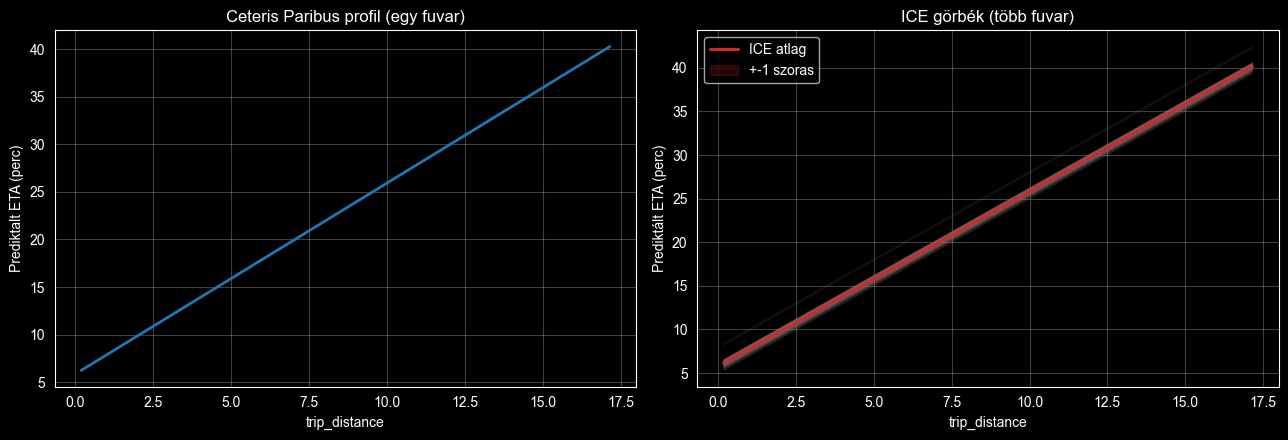

CP átlagos lokál slope (perc / távolság-egység): 2.0057
Interpretacio: pozitiv slope eseten a tav novekedese atlagosan noveli az ETA-t az adott helyi tartomanyban.


In [41]:
import matplotlib.pyplot as plt

feature_for_profile = 'trip_distance'
q_low = float(X_test[feature_for_profile].quantile(0.01))
q_high = float(X_test[feature_for_profile].quantile(0.99))
profile_grid = np.linspace(q_low, q_high, 40)

cp_instance = X_test.iloc[[0]].copy()
cp_rows = []
for v in profile_grid:
    x_mod = cp_instance.copy()
    x_mod.loc[:, feature_for_profile] = float(v)
    pred = float(selected_model.predict(x_mod)[0])
    cp_rows.append({'feature': feature_for_profile, 'feature_value': float(v), 'predicted_eta_min': pred})
cp_df = pd.DataFrame(cp_rows)

ice_sample_n = min(80, len(X_test))
ice_sample = X_test.sample(n=ice_sample_n, random_state=42).copy()
ice_curves = np.empty((ice_sample_n, len(profile_grid)), dtype=float)

for j, v in enumerate(profile_grid):
    x_mod = ice_sample.copy()
    x_mod.loc[:, feature_for_profile] = float(v)
    ice_curves[:, j] = selected_model.predict(x_mod)

ice_mean = ice_curves.mean(axis=0)
ice_std = ice_curves.std(axis=0)

ice_summary_df = pd.DataFrame({'feature_value': profile_grid, 'ice_mean_prediction': ice_mean, 'ice_std_prediction': ice_std})

print(f'Model-agnosztikus lokális vizsgálatok modellje: {selected_model_name}')
print(f'Vizsgált feature: {feature_for_profile}')
print(f'CP megfigyelés indexe: {int(cp_instance.index[0])}')
print(f'ICE mintaméret: {ice_sample_n}')
print('CP profil (elso 10 sor):')
display(cp_df.head(10))
print('ICE összegző profil (elso 10 sor):')
display(ice_summary_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(cp_df['feature_value'], cp_df['predicted_eta_min'], color='tab:blue', linewidth=2)
axes[0].set_title('Ceteris Paribus profil (egy fuvar)')
axes[0].set_xlabel(feature_for_profile)
axes[0].set_ylabel('Prediktalt ETA (perc)')
axes[0].grid(alpha=0.25)

for i in range(ice_sample_n):
    axes[1].plot(profile_grid, ice_curves[i], color='gray', alpha=0.15, linewidth=0.8)
axes[1].plot(profile_grid, ice_mean, color='tab:red', linewidth=2.2, label='ICE atlag')
axes[1].fill_between(profile_grid, ice_mean - ice_std, ice_mean + ice_std, color='tab:red', alpha=0.18, label='+-1 szoras')
axes[1].set_title('ICE görbék (több fuvar)')
axes[1].set_xlabel(feature_for_profile)
axes[1].set_ylabel('Prediktált ETA (perc)')
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

cp_slope = (cp_df['predicted_eta_min'].iloc[-1] - cp_df['predicted_eta_min'].iloc[0]) / (cp_df['feature_value'].iloc[-1] - cp_df['feature_value'].iloc[0])
print(f'CP átlagos lokál slope (perc / távolság-egység): {cp_slope:.4f}')
print('Interpretacio: pozitiv slope eseten a tav novekedese atlagosan noveli az ETA-t az adott helyi tartomanyban.')


### Ceteris Paribus és ICE eredmények értelmezése

- **Lokális hatás (CP):** ha a CP-görbe emelkedő, akkor az adott fuvarnál a `trip_distance` növelése emeli az ETA-becslést; ez összhangban van a lineáris modell fizikai értelmezésével.
- **Heterogenitás (ICE):** ha az ICE-görbék többsége emelkedő, akkor a távolság hatása nemcsak egyetlen mintánál, hanem több egyedi fuvarnál is stabilan pozitív.
- **Variabilitás:** a görbék közti szórás (`ice_std_prediction`) mutatja, hogy azonos távolság mellett más feature-ök (idő, koordináták) miatt mennyire változhat az ETA.
- **Model-agnosztikus validáció:** mivel a CP/ICE kizárólag predikció-lekérdezésre épül, a következtetés független a modell belső szerkezetétől.

## Globális model-agnosztikus vizsgálat: PDP a `trip_distance` változóra

A Partial Dependence Plot (PDP) azt mutatja meg, hogy a `trip_distance` változása átlagosan
hogyan módosítja a modell predikcióját a teljes mintán.

Ez egy globális és model-agnosztikus módszer: bármely prediktív modellre alkalmazható,
ha elérhető a `predict` függvénye.


PDP modell: Ridge (best alpha)
Vizsgált változók: ['trip_distance', 'pickup_hour', 'pickup_weekday']


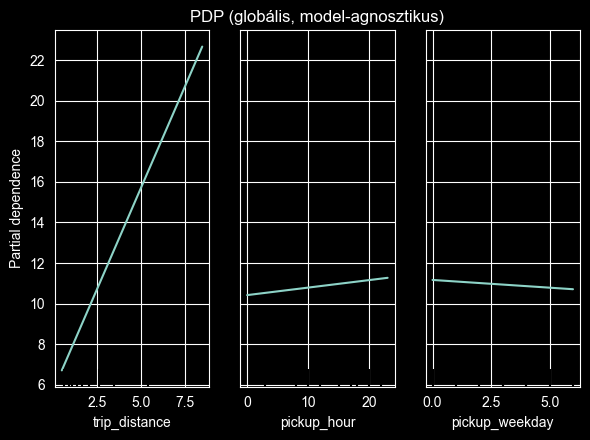

In [47]:
pdp_feature = ['trip_distance', 'pickup_hour', 'pickup_weekday']
print(f'PDP modell: {selected_model_name}')
print(f'Vizsgált változók: {pdp_feature}')

X_pdp = X_test.astype('float64').copy()

fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
PartialDependenceDisplay.from_estimator(
    selected_model,
    X_pdp,
    features=pdp_feature,
    kind='average',
    grid_resolution=40,
    ax=ax,
)
ax.set_title('PDP (globális, model-agnosztikus)')
plt.tight_layout()
plt.show()
